# Salt-finger convection using Dedalus 3

This notebook presents a Python code for simulating salt-finger convections in works by [Chang Liu 2022 JFM](https://doi.org/10.1017/jfm.2022.865) by using [Dedalus framework](https://dedalus-project.org/) which performs the spectral method. In particular, we consider a fliud between two infinitely long parallel plates with a distance $h$. The temperature ($T_*$) and salinity $S_*$ at these two plates are maintained at constant values with the top plate maintained at a higher temperature and salinity. The subscript $∗$ denotes a dimensional variable. Variables are non-dimensionalized based on the thermal diffusivity $\kappa_T$

\begin{equation}
T = \frac{T_*}{\Delta T}, \quad S = \frac{S_*}{\Delta S}, \quad t = \frac{t_*}{h^2/\kappa_T}, \quad \vec{u} = \frac{\vec{u}_*}{\kappa_T/h}, \quad p = \frac{p_*}{\kappa_T^2 \rho_{r*}/h^2}.
\end{equation}


In [89]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3

In this work, I use a computational domain of $[L_x\times L_z]:=[2\pi/k_x\times 1]$ with $k_x$ representing the wavenumber in the horizontal direction. Fourier and Shebyshev spectral methods are used in the horizontal and vertical directions with $N_x = 128$ and $N_z = 128$, respectively. Dealiasing scaling factor is set by $3/2$.


In [90]:
# Parameters
kx, kz = 1, 1 # wavenumber
Lx, Lz = 2*np.pi/kx, 1./kz    # computational domain
Nx, Nz = 128, 128       # number of points
dealias = 3/2           # scaling factor

The system is governed by (equation 2.2 in the reference)

\begin{equation}
\nabla\cdot \vec{u} = 0,
\end{equation}

\begin{equation}
\partial_t \vec{u}+\vec{u}\cdot\nabla\vec{u} = Pr\nabla^2\vec{u} -\nabla p + PrRa_{T}(T-R_{\rho}^{-1}S)\vec{e}_z,
\end{equation}

\begin{equation}
\partial_t T +\vec{u}\cdot\nabla T + w = \nabla^2 T,
\end{equation}

\begin{equation}
\partial_t S +\vec{u}\cdot\nabla S + w = \tau\nabla^2 S.
\end{equation}

where $\vec{u}$, $p$, and $\vec{e}_z$ are the fluid velocity, pressure, unit vector in the vertical. The governing parameters include the Prandtl number, the diffusivity ratio, the density ratio and the thermal Rayleigh number defined by

\begin{equation}
Ra := \frac{g\alpha\Delta T h^3}{\nu\kappa_T}, \quad Pr := \frac{\nu}{\kappa_T}, \quad \tau := \frac{\kappa_S}{\kappa_T}, \quad R_\rho := \frac{\alpha \Delta T}{\beta\Delta S},  
\end{equation}

where $\nu$ is the viscosity and $\kappa_S$ is the salinity diffusivity.

## Parameter values were used in reference work
Fixed Paramesters's value:
| Ra | $\tau$ |
|----|----|
| $10^5$ | 0.01|

Case 1: low Pr (=0.05)

| $R_p$|2|40|
|--|--|--|

Case 2: high Pr (=7)

| $R_p$|0.1|0.2|0.5|1|2|5|10|20|30|40|50|60|70|80|90|100|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|

In [91]:
Ra = 1e5    # Rayleigh number
Pr = 7     # Prandtl number
tau = 0.01 # diffusivity ratio = ks/kt
Rp = 40.0 # density ratio

To begin with, we must create basis for problem, including the mesh system based on the 2D Cartesian coordinate system and defination of field distributor with floating point in double precision.

In [92]:
# Bases
coords = d3.CartesianCoordinates('x','z')
dist = d3.Distributor(coords, dtype=np.float64)

There is a periodic boundary condition in horizontal direction, so we use Fourier for this direction (x axis). The no-periodic in vertical direction (z axis), the method of Chebyshev will be used there.

In [93]:
# define the coordinate system
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)

Now, we will instantiate fields which will appears within the problem using the distributor, including pressure $p$, velocity $\vec{u}$, temperature $T$, and salinity $S$.

In [94]:
# define fields
p = dist.Field(name='p', bases=(xbasis,zbasis)) # create pressure field with scalar type
u = dist.VectorField(coords, name='u', bases=(xbasis,zbasis)) # create velocity field with vectoral type

sa = dist.Field(name='sa', bases=(xbasis,zbasis)) # create salinity field with scalar type
te = dist.Field(name='te', bases=(xbasis,zbasis)) # create temperature field with scalar type

To simply when typing and determining the equations in Dedalus3, we can define replace operators for complex operators

In [95]:
# Substitutions
x, z = dist.local_grids(xbasis, zbasis) # get coordinate arrays in horizontal and vertical directions
ex, ez = coords.unit_vector_fields(dist) # get unit vectors in horizontal and vertical directions

In [96]:
# define velocity component in vertical direction
w = u @ ez

lift_basis = zbasis.derivative_basis(1) 
lift = lambda A: d3.Lift(A, lift_basis, -1)

## Define problem's equations

First, we consider continuity equation for the incompressible flow condition:

\begin{equation}
\nabla\cdot \vec{u} = 0
\end{equation}

When implementing this divergence equation, there is a few error if one variable is underdetermined. So, we will use Gauge condition in present Dedalus v3, read [here](https://dedalus-project.readthedocs.io/en/latest/pages/gauge_conditions.html). Here, the divergence equation is expanded the system by adding a spatially-constant variable ($\tau_p$) for solving pressure field. As a result, the equation is replaced by

\begin{equation}
\nabla\cdot \vec{u} + \tau_p= 0
\end{equation}

In Dedalus, we need to create a corresponding sub-field for $\tau_p$

In [97]:


# create constant sub-field for incompressible flow condition's equation
tau_p = dist.Field(name='tau_p') 
# because this term is only a contant added to the equation, we don't need to instantiate it for bases system

tau_te1 = dist.Field(name='tau_te1', bases=xbasis)
tau_te2 = dist.Field(name='tau_te2', bases=xbasis)
grad_te = d3.grad(te) + ez*lift(tau_te1) # First-order reduction

# create constant sub-field for bouyancy term
tau_sa1 = dist.Field(name='tau_sa1', bases=xbasis)
tau_sa2 = dist.Field(name='tau_sa2', bases=xbasis)
grad_sa = d3.grad(sa) + ez*lift(tau_sa1) # First-order reduction

tau_u1 = dist.VectorField(coords, name='tau_u1', bases=xbasis) 
tau_u2 = dist.VectorField(coords, name='tau_u2', bases=xbasis)
grad_u = d3.grad(u) + ez*lift(tau_u1) # First-order reduction


# First-order form: "lap(f)" becomes "div(grad_f)"
lap_u = d3.div(grad_u)
lap_te = d3.div(grad_te)
lap_sa = d3.div(grad_sa)

When we have all the fields for solving, we must build the IVP problem and introcude fields to the solver. At this step, we don't have full field for solving all three governing equations, so we just introduce corresponding codes to perform this.

In [98]:
# Problem
problem = d3.IVP([p, tau_p, u, tau_u1, tau_u2, te, tau_te1, tau_te2, sa, tau_sa1, tau_sa2], namespace=locals())

Adding the first equation

\begin{equation}
tr(\nabla\cdot \vec{u}) + \tau_p = 0
\end{equation}

In [99]:
# First-order form: "div(A)" becomes "trace(grad_A)"

# Continuity Equation
problem.add_equation("trace(grad_u) + tau_p = 0")
problem.add_equation("integ(p) = 0") # Pressure gauge

{'LHS': Integrate(Integrate(<Field 139950181671392>)),
 'RHS': 0,
 'condition': 'True',
 'tensorsig': (),
 'dtype': numpy.float64,
 'M': 0,
 'L': Integrate(Integrate(<Field 139950181671392>)),
 'F': <Field 139954253287536>,
 'domain': <dedalus.core.domain.Domain at 0x7f48b0e7c080>,
 'matrix_dependence': array([ True,  True]),
 'matrix_coupling': array([False,  True])}

Adding the momentum equation

\begin{equation}
\partial_t \vec{u} - Pr\nabla^2\vec{u} +\nabla p - PrRa_{T}(T-R_{\rho}^{-1}S)\vec{e}_z = -\vec{u}\cdot\nabla\vec{u}
\end{equation}

In [100]:
# equation 2
problem.add_equation("dt(u) - Pr*lap_u + grad(p) - Pr*Ra*(te-(1./Rp)*sa)*ez + lift(tau_u2) = - u@grad(u)")

{'LHS': Add(Add(Add(Add(Convert(dt(<Field 139950209832896>)), Mul(-1, Mul(7, Div(Add(Grad(<Field 139950209832896>), Mul(<Field 139950182359280>, Mul(<Field 139950206673568>, <Field 139950182361824>))))))), Convert(Grad(<Field 139950181671392>))), Convert(Mul(-1, Mul(Mul(700000.0, Add(<Field 139950209839232>, Mul(-1, Mul(0.025, <Field 139950209841872>)))), <Field 139950182359280>)))), Convert(Mul(<Field 139950206673568>, <Field 139950182365664>))),
 'RHS': Dot(Mul(-1, <Field 139950209832896>), Grad(<Field 139950209832896>)),
 'condition': 'True',
 'tensorsig': (<dedalus.core.coords.CartesianCoordinates at 0x7f48b0e7c0e0>,),
 'dtype': dtype('float64'),
 'M': Convert(<Field 139950209832896>),
 'L': Add(Add(Add(Mul(-1, Mul(7, Div(Add(Grad(<Field 139950209832896>), Mul(<Field 139950182359280>, Mul(<Field 139950206673568>, <Field 139950182361824>)))))), Convert(Grad(<Field 139950181671392>))), Convert(Mul(-1, Mul(Mul(700000.0, Add(<Field 139950209839232>, Mul(-1, Mul(0.025, <Field 1399502098

Adding the governing equation for temperature

\begin{equation}
\partial_t T - \nabla^2 T + w = -\vec{u}\cdot\nabla T
\end{equation}

In [101]:
# equation 3
problem.add_equation("dt(te) - lap_te + w + lift(tau_te2) = - u@grad(te)")

{'LHS': Add(Add(Add(Convert(dt(<Field 139950209839232>)), Mul(-1, Div(Add(Grad(<Field 139950209839232>), Mul(<Field 139950182359280>, Mul(<Field 139950206673568>, <Field 139950182363408>)))))), Convert(Dot(<Field 139950209832896>, <Field 139950182359280>))), Convert(Mul(<Field 139950206673568>, <Field 139950182353712>))),
 'RHS': Dot(Mul(-1, <Field 139950209832896>), Grad(<Field 139950209839232>)),
 'condition': 'True',
 'tensorsig': (),
 'dtype': dtype('float64'),
 'M': Convert(<Field 139950209839232>),
 'L': Add(Add(Mul(-1, Div(Add(Grad(<Field 139950209839232>), Mul(<Field 139950182359280>, Mul(<Field 139950206673568>, <Field 139950182363408>))))), Convert(Dot(<Field 139950209832896>, <Field 139950182359280>))), Convert(Mul(<Field 139950206673568>, <Field 139950182353712>))),
 'F': Convert(Dot(Mul(-1, <Field 139950209832896>), Grad(<Field 139950209839232>))),
 'domain': <dedalus.core.domain.Domain at 0x7f48b2f5e6f0>,
 'matrix_dependence': array([ True,  True]),
 'matrix_coupling': ar

Adding the governing equation for salanity

\begin{equation}
\partial_t S - \tau\nabla^2 S + w = -\vec{u}\cdot\nabla S
\end{equation}

In [102]:
# equation 3
problem.add_equation("dt(sa) - tau*lap_sa + w + lift(tau_sa2) = - u@grad(sa)")

{'LHS': Add(Add(Add(Convert(dt(<Field 139950209841872>)), Mul(-1, Mul(0.01, Div(Add(Grad(<Field 139950209841872>), Mul(<Field 139950182359280>, Mul(<Field 139950206673568>, <Field 139950196106512>))))))), Convert(Dot(<Field 139950209832896>, <Field 139950182359280>))), Convert(Mul(<Field 139950206673568>, <Field 139950182360048>))),
 'RHS': Dot(Mul(-1, <Field 139950209832896>), Grad(<Field 139950209841872>)),
 'condition': 'True',
 'tensorsig': (),
 'dtype': dtype('float64'),
 'M': Convert(<Field 139950209841872>),
 'L': Add(Add(Mul(-1, Mul(0.01, Div(Add(Grad(<Field 139950209841872>), Mul(<Field 139950182359280>, Mul(<Field 139950206673568>, <Field 139950196106512>)))))), Convert(Dot(<Field 139950209832896>, <Field 139950182359280>))), Convert(Mul(<Field 139950206673568>, <Field 139950182360048>))),
 'F': Convert(Dot(Mul(-1, <Field 139950209832896>), Grad(<Field 139950209841872>))),
 'domain': <dedalus.core.domain.Domain at 0x7f48b2f5e6f0>,
 'matrix_dependence': array([ True,  True]),


## Set up the boundary conditions


Researching vertically confined salt-finger convection helps people to understand the interior between two well-mixed layers. The temperature and salanity are imposed as constant variables roling boundary conditions in this simulation.

\begin{equation}
T(x,z=0,t)=T(x,z=Lz,t)=0
\end{equation}

\begin{equation}
S(x,z=0,t)=S(x,z=Lz,t)=0
\end{equation}

In [103]:
# for temperature
problem.add_equation("te(z=0) = 0")
problem.add_equation("te(z=Lz) = 0")
# for salinity
problem.add_equation("sa(z=0) = 0")
problem.add_equation("sa(z=Lz) = 0")

{'LHS': interp(<Field 139950209841872>, z=1.0),
 'RHS': 0,
 'condition': 'True',
 'tensorsig': (),
 'dtype': numpy.float64,
 'M': 0,
 'L': interp(<Field 139950209841872>, z=1.0),
 'F': <Field 139950216826896>,
 'domain': <dedalus.core.domain.Domain at 0x7f48b0e7ef30>,
 'matrix_dependence': array([False,  True]),
 'matrix_coupling': array([False,  True])}

To approach laboratory experiments more, the no-slip boudanry condition for velocity is adopted at top and bottom planes. In some cases, we can use the stress-free velocity boundary conditions instead to understand oceanographic scenarios. The no-slip boudanry condition for velocity in present situation is defined by

\begin{equation}
\vec{u}(x,z=0,t)=\vec{u}(x,z=Lz,t)=0
\end{equation}

In [104]:
# no-slip condition for velocity at top and bottom planes
problem.add_equation("u(z=0) = 0")
problem.add_equation("u(z=Lz) = 0")

{'LHS': interp(<Field 139950209832896>, z=1.0),
 'RHS': 0,
 'condition': 'True',
 'tensorsig': (<dedalus.core.coords.CartesianCoordinates at 0x7f48b0e7c0e0>,),
 'dtype': numpy.float64,
 'M': 0,
 'L': interp(<Field 139950209832896>, z=1.0),
 'F': <Field 139950177399728>,
 'domain': <dedalus.core.domain.Domain at 0x7f48b0e7ef30>,
 'matrix_dependence': array([False,  True]),
 'matrix_coupling': array([False,  True])}

## Build Solver

In [105]:
stop_sim_time = 300 # Stopping criteria
timestepper = d3.RK443 # 3rd-order 4-stage DIRK+ERK scheme [Ascher 1997 sec 2.8] https://doi-org.ezproxy.lib.uconn.edu/10.1016/S0168-9274(97)00056-1
# timestepper = d3.RK222
# Solver
solver = problem.build_solver(timestepper)
solver.stop_sim_time = stop_sim_time

2024-07-11 21:36:43,473 subsystems 0/1 INFO :: Building subproblem matrices 1/64 (~2%) Elapsed: 1s, Remaining: 36s, Rate: 1.8e+00/s
2024-07-11 21:36:45,000 subsystems 0/1 INFO :: Building subproblem matrices 7/64 (~11%) Elapsed: 2s, Remaining: 17s, Rate: 3.3e+00/s
2024-07-11 21:36:46,304 subsystems 0/1 INFO :: Building subproblem matrices 14/64 (~22%) Elapsed: 3s, Remaining: 12s, Rate: 4.1e+00/s
2024-07-11 21:36:47,537 subsystems 0/1 INFO :: Building subproblem matrices 21/64 (~33%) Elapsed: 5s, Remaining: 9s, Rate: 4.5e+00/s
2024-07-11 21:36:48,916 subsystems 0/1 INFO :: Building subproblem matrices 28/64 (~44%) Elapsed: 6s, Remaining: 8s, Rate: 4.7e+00/s
2024-07-11 21:36:50,434 subsystems 0/1 INFO :: Building subproblem matrices 35/64 (~55%) Elapsed: 8s, Remaining: 6s, Rate: 4.7e+00/s
2024-07-11 21:36:51,533 subsystems 0/1 INFO :: Building subproblem matrices 42/64 (~66%) Elapsed: 9s, Remaining: 5s, Rate: 4.9e+00/s
2024-07-11 21:36:52,688 subsystems 0/1 INFO :: Building subproblem ma

### Set up initial conditions

In [106]:
te.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
# te['g'] *= z * (Lx - z) # Damp noise at walls
# te['g'] += z # Add linear background

sa.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
# sa['g'] *= z * (Lx - z) # Damp noise at walls
# sa['g'] += z # Add linear background

In [107]:
# Analysis
import shutil, os
sim_name = 'DNS'
if os.path.exists(sim_name):
    shutil.rmtree(sim_name) # remove the output directory and its previous contents

dataset = solver.evaluator.add_file_handler(sim_name, sim_dt=1.0, max_writes=1000)
dataset.add_task(te, name='temperature')
dataset.add_task(sa, name='salinity')
dataset.add_task(p, name='pressure')
dataset.add_task(u@ex, name='velocity_u')
dataset.add_task(u@ez, name='velocity_w')
dataset.add_task(-d3.div(d3.skew(u)), name='vorticity')


In [108]:
max_timestep = 0.125
# CFL
CFL = d3.CFL(solver, initial_dt=max_timestep, cadence=10, safety=0.5, threshold=0.05,
             max_change=1.5, min_change=0.5, max_dt=max_timestep)
CFL.add_velocity(u)

In [109]:
# Flow properties
# flow = d3.GlobalFlowProperty(solver, cadence=10)
# flow.add_property(np.sqrt(u@u)/nu, name='Re')

Starting main loop
Completed iteration 1, time=0.125


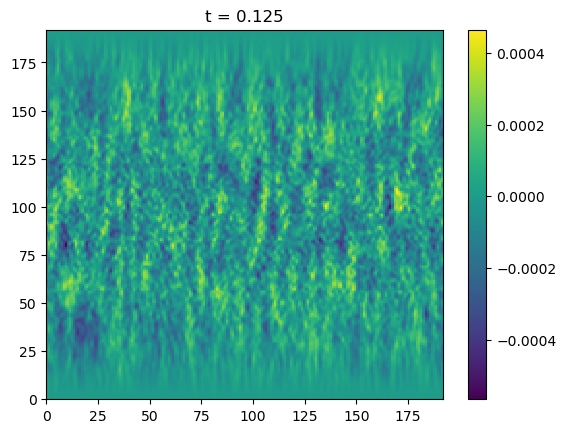

Completed iteration 101, time=6.509


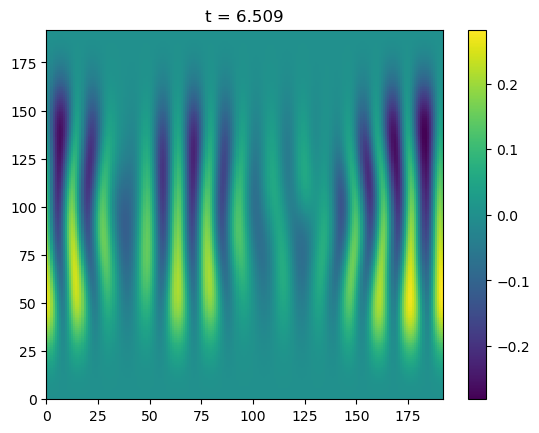

Completed iteration 201, time=7.341


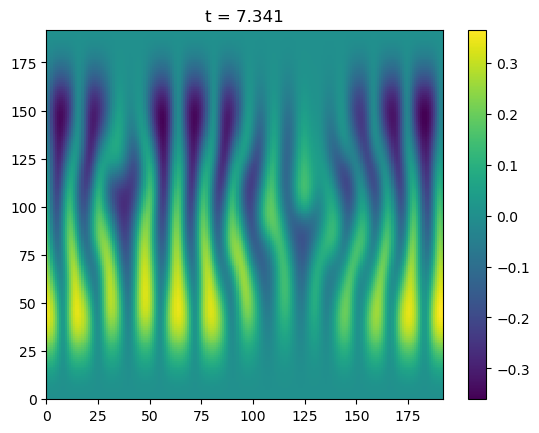

Completed iteration 301, time=8.177


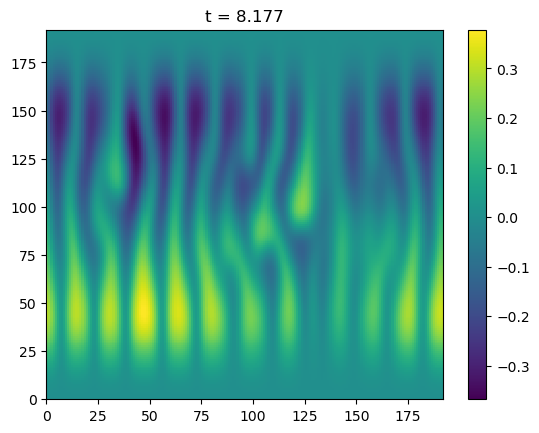

Completed iteration 401, time=9.062


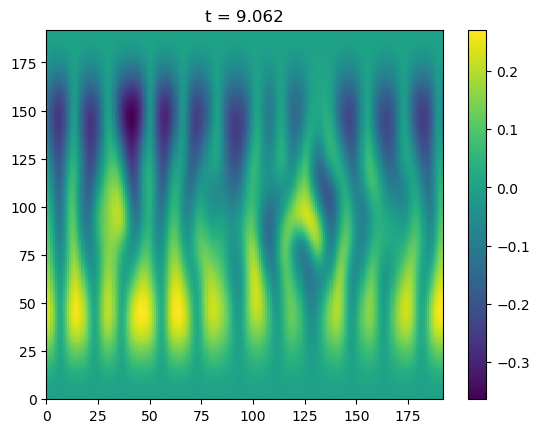

Completed iteration 501, time=10.076


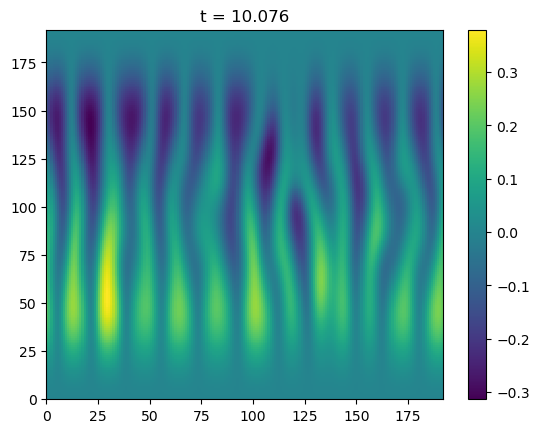

Completed iteration 601, time=10.979


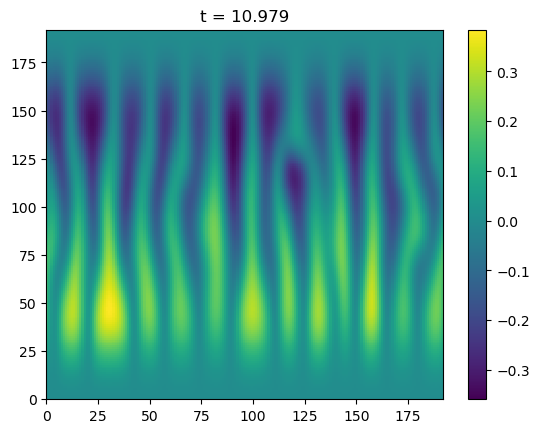

Completed iteration 701, time=11.876


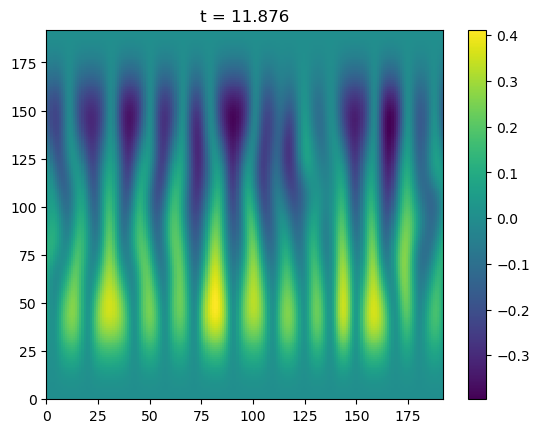

Completed iteration 801, time=12.731


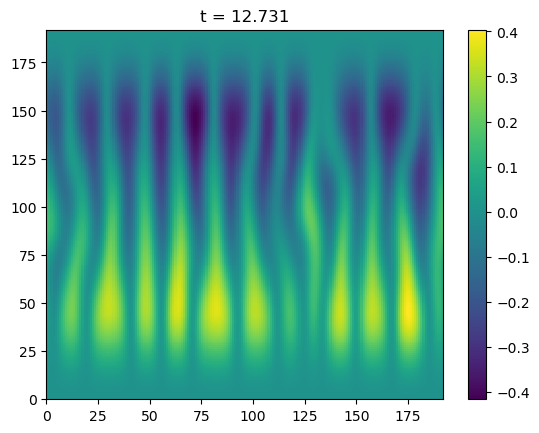

Completed iteration 901, time=13.591


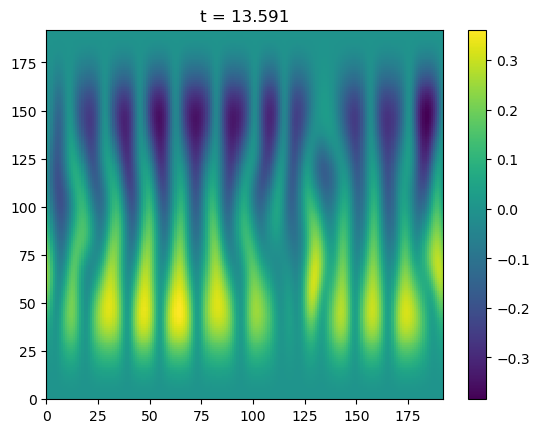

Completed iteration 1001, time=14.492


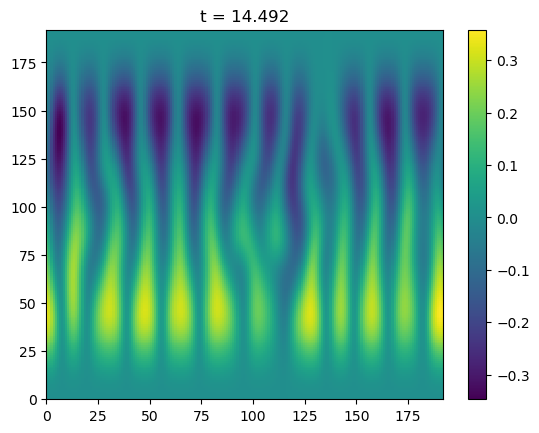

Completed iteration 1101, time=15.428


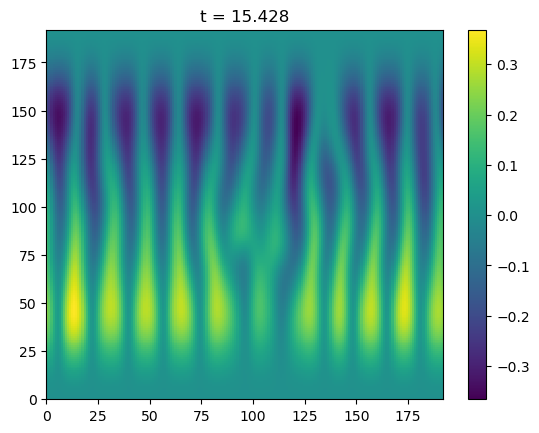

KeyboardInterrupt: 

In [110]:
# Setup storage
# barS0.change_scales(1)
# barS0_list = [np.copy(barS0['g'])]
# t_list = [solver.sim_time]

# Main loop
print('Starting main loop')
while solver.proceed:
    timestep = CFL.compute_timestep()
    solver.step(timestep)
    if (solver.iteration-1) % 100 == 0:
        print('Completed iteration {}, time={:.3f}'.format(solver.iteration, solver.sim_time))
        sa_plot = plt.pcolormesh(np.copy(sa['g']).transpose())
        plt.colorbar(sa_plot) 
        plt.title("t = {:.3f}".format(solver.sim_time))
        # plt.savefig("salinity{:.3f}.png".format(solver.sim_time), dpi=200)
        plt.show()
        # plt.close()